# Part 1: Multi-Class Sequence Classification with BERT

We are performing **Sentiment Analysis** on tweets.

In [193]:
!pip install torch -q
!pip install transformers -q
!pip install kagglehub -q
!pip install scipy -q
!pip install bitsandbytes>=0.39.0 -q

In [3]:
# Import the libraries we need

import time
import datetime
import pandas as pd
import numpy as np
import random

import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import TensorDataset, random_split
from torch.utils.data import RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertModel
from transformers import BertForSequenceClassification, AdamW, BertConfig
from transformers import get_linear_schedule_with_warmup
import kagglehub

In [4]:
# If there's a GPU available...
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

No GPU available, using the CPU instead.


## Open our data

In [6]:
path = kagglehub.dataset_download('abhi8923shriv/sentiment-analysis-dataset')
print('Data source import complete.')

Data source import complete.


In [7]:
# Open the data files

# Data file names
train_dataset = path +'/train.csv'
test_dataset = path +'/test.csv'

# Check if the files exist and all is good
# print(os.path.exists(train_dataset))
# print(os.path.exists(test_dataset))

# Load the CSV files into a DataFrame
train_df = pd.read_csv(train_dataset, encoding='ISO-8859-1')
test_df = pd.read_csv(test_dataset, encoding='ISO-8859-1')

In [8]:
# Clean up lines in the dataframes that are empty
train_df = train_df[train_df['text'].notna()]
train_df = train_df[train_df['sentiment'].notna()]
test_df = test_df[test_df['text'].notna()]
test_df = test_df[test_df['sentiment'].notna()]

# Report the number of sentences.
print('Number of training sentences (before validation split): {:,}\n'.format(train_df.shape[0]))
print('Number of test sentences: {:,}\n'.format(test_df.shape[0]))

# Display 5 random rows from the data.
train_df.sample(5)

Number of training sentences (before validation split): 27,480

Number of test sentences: 3,534



,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
25780,66a3b2a036,Swollen face.....again,Swollen face.....again,negative,noon,60-70,Tuvalu,11792,30.0,393
21310,7f4ebd7979,If there is one thing the Internet has taught ...,If there is one thing the Internet has taught ...,neutral,noon,60-70,United Arab Emirates,9890402,83600.0,118
10632,756b4e674b,Stupid competition stuff keeps getting in the ...,Stupid competition stuff,negative,morning,0-20,Guinea,13132795,246000.0,53
24002,c62590abcd,"Shiv, his place, slowly I hope",y I ho,positive,night,31-45,Kiribati,119449,810.0,147
12951,31dbee3a36,Up was pretty good. It was kind of depressing ...,Up was pretty good. It was kind of depressing ...,neutral,morning,46-60,Mozambique,31255435,786380.0,40


In [9]:
# Get the lists of sentences and their labels.

# Train and validation sentences + labels
train_val_sentences = train_df.text.values    # list of sentences
train_val_labels = train_df.sentiment.values  # list of labels

# Test sentences + labels
test_sentences = test_df.text.values    # list of sentences
test_labels = test_df.sentiment.values  # list of labels

In [10]:
# Split the train_val lists into train and validation

# 10% of train sentences will be hidden and used for validation
# 90% of train sentences will be the actual training set.
# We can change the ratio as we desire.
train_cutoff = int(len(train_val_sentences) * 0.9)

# First 90% sentences are used for training
train_sentences = train_val_sentences[:train_cutoff]
train_labels = train_val_labels[:train_cutoff]

# Last 10% sentences are used for validation
val_sentences = train_val_sentences[train_cutoff:]
val_labels = train_val_labels[train_cutoff:]

print('Number of training + validation sentences:\t', len(train_sentences))
print('Number of validation sentences:\t', len(val_sentences))
print('Number of test sentences:\t', len(test_sentences))

Number of training + validation sentences:	 24732
Number of validation sentences:	 2748
Number of test sentences:	 3534


In [12]:
# Looking at our labels: we only, only look at training labels!
# If there are labels in validation or test that do not exist in training,
# they should always be treated as unknown labels! We only learn from training data.
# This time, we don't have unkown labels... but keep in mind for the future!

counted_train_labels = dict(Counter(train_labels))
print('Number of training labels:', counted_train_labels)

# Make a vocabulary for our labels
label_encodings = {v:k for k, v in (enumerate(counted_train_labels.keys()))}
inverse_label_encodings = {v:k for k, v in label_encodings.items()}
print('Label encodings:', label_encodings)

# Make a function to encode the labels to integers

def encode_labels_to_integers(list_of_labels, label_encodings):
  encoded_labels = [label_encodings[x] for x in list_of_labels]

  return encoded_labels

# Encode all the labels!
encoded_train_labels = encode_labels_to_integers(train_labels, label_encodings)
encoded_val_labels = encode_labels_to_integers(val_labels, label_encodings)
encoded_test_labels = encode_labels_to_integers(test_labels, label_encodings)

Number of training labels: {'neutral': 199, 'negative': 154, 'positive': 147}
Label encodings: {'neutral': 0, 'negative': 1, 'positive': 2}


## Make a bar plot to visualize our data

We will use matplotlib bar.
The documentation, with examples, can be found here: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

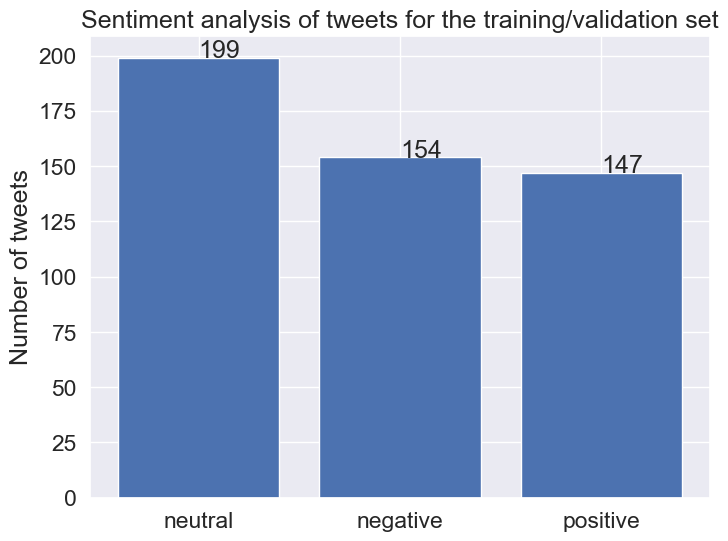

In [189]:
# Make a bar plot to visualize how many labels we have
# We can use matplotlib and give it our counted labels

%matplotlib inline

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (8,6)

# The data that we plot comes from the dictionary `counted_train_labels`

# matplotlib bar needs two dimensions: x and y
# x = the labels we are plotting
# y = the count of each label

# matplotlib DOES NOT like dictionaries! it needs an x list and a y list

x = list(counted_train_labels.keys())
y = list(counted_train_labels.values())

# function to add value labels on top of bars
def add_labels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i])

plt.bar(x,y)
add_labels(x,y)

plt.ylabel('Number of tweets')
plt.title('Sentiment analysis of tweets: training/validation set')

plt.show()


In [231]:
# Homework: show statistics on test set!

# Careful! You will need to count the test set before!

## Encoding the sequence

In [234]:
# We have to decide which model to use
MODEL_NAME = "bert-base-uncased"
# We will use this variable later in training as well

# Load the model's tokenizer.
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME, do_lower_case=True)

Loading BERT tokenizer...


In [17]:
# Print the original sentence.
print(' Original: ', train_sentences[0])
# Print the sentence split into tokens.
print('Tokenized: ', tokenizer.tokenize(train_sentences[0]))
# Print the sentence mapped to token ids.
print('Token IDs: ', tokenizer.convert_tokens_to_ids(tokenizer.tokenize(train_sentences[0])))

 Original:   I`d have responded, if I were going
Tokenized:  ['i', '`', 'd', 'have', 'responded', ',', 'if', 'i', 'were', 'going']
Token IDs:  [1045, 1036, 1040, 2031, 5838, 1010, 2065, 1045, 2020, 2183]


In [18]:
# We find the maximum length of our training sentences

max_len = 0

# For every sentence...
for sent in train_sentences:
    # Tokenize the text and add `[CLS]` and `[SEP]` tokens.
    input_ids = tokenizer.encode(sent, add_special_tokens=True)
    # Update the maximum sentence length.
    max_len = max(max_len, len(input_ids))

print('Max sentence length: ', max_len)

Max sentence length:  59


## Tokenization & Encoding

### Tokenize and encode the training set!

In [21]:
# Tokenize all of the train sentences and map the tokens to their word IDs.
train_input_ids = []
train_attention_masks = []

# For the training set
for sent in train_sentences:
    encoded_dict = tokenizer.encode_plus(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 64,           # Pad & truncate all sentences.
                        padding='max_length',
                        truncation=True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )

    # Add the encoded sentence to the list.
    train_input_ids.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    train_attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
train_input_ids = torch.cat(train_input_ids, dim=0)
train_attention_masks = torch.cat(train_attention_masks, dim=0)
tensor_train_labels = torch.tensor(encoded_train_labels)

# Print sentence 0, now as a list of IDs.
print('Original: ', train_sentences[0])
print('Token IDs:', train_input_ids[0])

Original:   I`d have responded, if I were going
Token IDs: tensor([ 101, 1045, 1036, 1040, 2031, 5838, 1010, 2065, 1045, 2020, 2183,  102,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])


### **TODO: Tokenize and encode the validation set!**

In [23]:
# Similar to how we encode the train set and the test set
# BE CAREFUL: we need these lists with these exact names
# Your task is to process each sentence in val_sentences and
# fill these lists with the input_ids and attention_masks
val_input_ids = []
val_attention_masks = []


# For the validation set
for sent in val_sentences:
    ## HOMEWORK!!

val_input_ids = torch.cat(val_input_ids, dim=0)
val_attention_masks = torch.cat(val_attention_masks, dim=0)
tensor_val_labels = torch.tensor(encoded_val_labels)

### Tokenize and encode the test set!

In [24]:
# Tokenize all of the test sentences and map the tokens to their word IDs.
test_input_ids = []
test_attention_masks = []

# For the test set
for sent in test_sentences:
    encoded_dict = tokenizer.encode_plus(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 64,           # Pad & truncate all sentences.
                        padding='max_length',
                        truncation=True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )

    test_input_ids.append(encoded_dict['input_ids'])
    test_attention_masks.append(encoded_dict['attention_mask'])

test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)
tensor_test_labels = torch.tensor(encoded_test_labels)

In [25]:
# Turn our lists into a TensorDataset, appropriate for processing

train_dataset = TensorDataset(train_input_ids, train_attention_masks, tensor_train_labels)
val_dataset = TensorDataset(val_input_ids, val_attention_masks, tensor_val_labels)
test_dataset = TensorDataset(test_input_ids, test_attention_masks, tensor_test_labels)

In [26]:
# The DataLoader needs to know our batch size for training, so we specify it
# here. For fine-tuning BERT on a specific task, the authors recommend a batch
# size of 16 or 32.
batch_size = 32

# Create the DataLoaders for our training and validation sets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
            train_dataset,  # The training samples.
            sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

# For validation the order doesn't matter, so we'll just read them sequentially.
validation_dataloader = DataLoader(
            val_dataset, # The validation samples.
            sampler = SequentialSampler(val_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

# For test the order doesn't matter either!
test_dataloader = DataLoader(
            test_dataset, # The validation samples.
            sampler = SequentialSampler(val_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

## Train Our Classification Model

In [28]:
# Load BertForSequenceClassification, the pretrained BERT model with a single linear classification layer on top.
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, # Use the 12-layer BERT model, with an uncased vocab.
    num_labels = len(label_encodings),
    output_attentions = False, # Whether the model returns attentions weights.
    output_hidden_states = False, # Whether the model returns all hidden-states.
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [36]:
# Tell pytorch to run this model on the GPU.
if torch.cuda.is_available():
    model.cuda()

In [38]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
# I believe the 'W' stands for 'Weight Decay fix"
optimizer = AdamW(model.parameters(),
                  lr = 2e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )


C:\Users\lenak\anaconda3\Lib\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [40]:
# Number of training epochs
epochs = 2

# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [42]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [44]:
def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))


We're ready to kick off the training!

In [47]:
# This training code is based on the `run_glue.py` script here:
# https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# We'll store a number of quantities such as training and validation loss,
# validation accuracy, and timings.
training_stats = []

# Measure the total training time for the whole run.
total_t0 = time.time()

# For each epoch...
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0

    # Put the model into training mode. Don't be mislead--the call to
    # `train` just changes the *mode*, it doesn't *perform* the training.
    # `dropout` and `batchnorm` layers behave differently during training
    # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 40 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using the
        # `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Always clear any previously calculated gradients before performing a
        # backward pass. PyTorch doesn't do this automatically because
        # accumulating the gradients is "convenient while training RNNs".
        # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
        model.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # In PyTorch, calling `model` will in turn call the model's `forward`
        # function and pass down the arguments. The `forward` function is
        # documented here:
        # https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification
        # The results are returned in a results object, documented here:
        # https://huggingface.co/transformers/main_classes/output.html#transformers.modeling_outputs.SequenceClassifierOutput
        # Specifically, we'll get the loss (because we provided labels) and the
        # "logits"--the model outputs prior to activation.
        result = model(b_input_ids,
                       token_type_ids=None,
                       attention_mask=b_input_mask,
                       labels=b_labels,
                       return_dict=True)

        loss = result.loss
        logits = result.logits

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_train_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epcoh took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    print("")
    print("Running Validation...")

    t0 = time.time()

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()

    # Tracking variables
    total_eval_accuracy = 0
    total_eval_loss = 0
    nb_eval_steps = 0

    # Evaluate data for one epoch
    for batch in validation_dataloader:

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using
        # the `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Tell pytorch not to bother with constructing the compute graph during
        # the forward pass, since this is only needed for backprop (training).
        with torch.no_grad():

            # Forward pass, calculate logit predictions.
            # token_type_ids is the same as the "segment ids", which
            # differentiates sentence 1 and 2 in 2-sentence tasks.
            result = model(b_input_ids,
                           token_type_ids=None,
                           attention_mask=b_input_mask,
                           labels=b_labels,
                           return_dict=True)

        # Get the loss and "logits" output by the model. The "logits" are the
        # output values prior to applying an activation function like the
        # softmax.
        loss = result.loss
        logits = result.logits

        # Accumulate the validation loss.
        total_eval_loss += loss.item()

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Calculate the accuracy for this batch of test sentences, and
        # accumulate it over all batches.
        total_eval_accuracy += flat_accuracy(logits, label_ids)


    # Report the final accuracy for this validation run.
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

    # Calculate the average loss over all of the batches.
    avg_val_loss = total_eval_loss / len(validation_dataloader)

    # Measure how long the validation run took.
    validation_time = format_time(time.time() - t0)

    print("  Validation Loss: {0:.2f}".format(avg_val_loss))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Loss': avg_val_loss,
            'Valid. Accur.': avg_val_accuracy,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")

print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 2 ========
Training...

  Average training loss: 1.09
  Training epcoh took: 0:03:09

Running Validation...
  Accuracy: 0.41
  Validation Loss: 1.10
  Validation took: 0:00:11

======== Epoch 2 / 2 ========
Training...

  Average training loss: 1.01
  Training epcoh took: 0:03:06

Running Validation...
  Accuracy: 0.44
  Validation Loss: 1.05
  Validation took: 0:00:11

Training complete!
Total training took 0:06:37 (h:mm:ss)


Let's view the summary of the training process.

In [52]:
# Display floats with two decimal places.
pd.set_option('display.precision', 2)
# Create a DataFrame from our training statistics.
df_stats = pd.DataFrame(data=training_stats)
# Use the 'epoch' as the row index.
df_stats = df_stats.set_index('epoch')
# Display the table.
df_stats

,Training Loss,Valid. Loss,Valid. Accur.,Training Time,Validation Time
epoch,,,,,
1,1.09,1.10,0.41,0:03:09,0:00:11
2,1.01,1.05,0.44,0:03:06,0:00:11


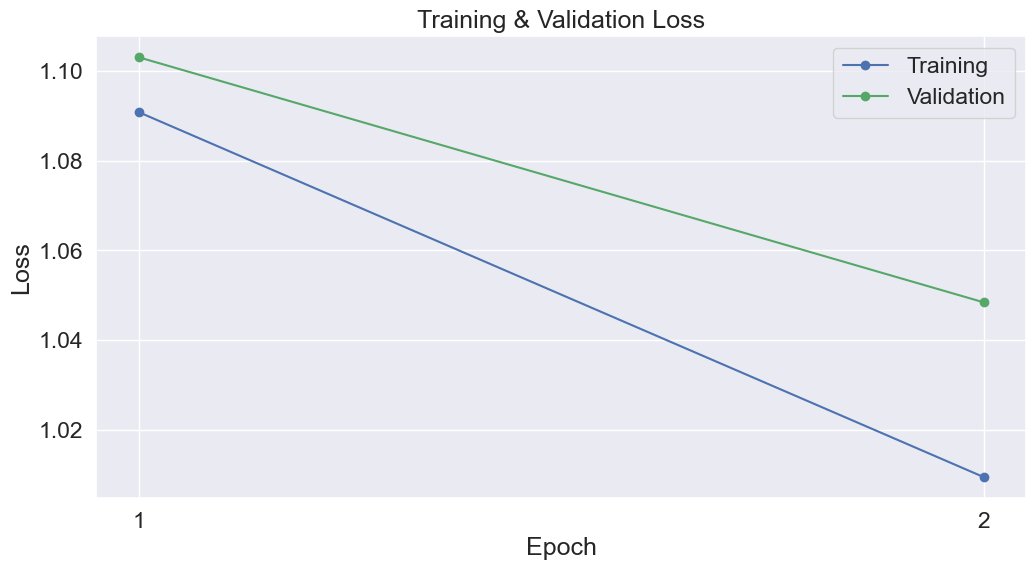

In [169]:
%matplotlib inline

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(df_stats['Training Loss'], 'b-o', label="Training")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation")

# Label the plot.
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks([x+1 for x in range(epochs)])

plt.show()

## Performance On Test Set

### Evaluate on Test Set


In [124]:
# Prediction on test set

print('Predicting labels for {:,} test sentences...'.format(len(test_input_ids)))

# Put model in evaluation mode
model.eval()

# Tracking variables
predictions , true_labels = [], []

# Predict
for batch in test_dataloader:
  # Add batch to GPU
  batch = tuple(t.to(device) for t in batch)

  # Unpack the inputs from our dataloader
  b_input_ids, b_input_mask, b_labels = batch

  # Telling the model not to compute or store gradients, saving memory and
  # speeding up prediction
  with torch.no_grad():
      # Forward pass, calculate logit predictions.
      result = model(b_input_ids,
                     token_type_ids=None,
                     attention_mask=b_input_mask,
                     return_dict=True)

  logits = result.logits

  # Move logits and labels to CPU
  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  # Store predictions and true labels
  predictions.append(logits)
  true_labels.append(label_ids)

print('    DONE.')

Predicting labels for 100 test sentences...
    DONE.


In [125]:
# Combine the results across all batches.
flat_predictions = np.concatenate(predictions, axis=0)
# For each sample, pick the label with the higher score.
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()

# Combine the correct labels for each batch into a single list.
flat_true_labels = np.concatenate(true_labels, axis=0)

# Make sure that the model has predicted a label for every test input.
assert len(flat_predictions.tolist()) == len(flat_true_labels.tolist())

## Looking at the prediction quality

In [146]:
# Look at the results with classification report

# Homework: with scikit-learn, print the accuracy score
print('Accuracy:')

print(classification_report(flat_true_labels.tolist(), flat_predictions.tolist(), 
                            target_names =['neutral', 'negative', 'positive']))

              precision    recall  f1-score   support

     neutral       0.42      0.64      0.50        44
    negative       0.40      0.40      0.40        30
    positive       1.00      0.12      0.21        26

    accuracy                           0.43       100
   macro avg       0.61      0.38      0.37       100
weighted avg       0.56      0.43      0.40       100



In [155]:
# Show correlation metrics
# We find correlations with SciPy
# https://docs.scipy.org/doc/scipy/reference/stats.html
from scipy import stats

print('Pearson r correlation:', stats.pearsonr(flat_true_labels.tolist(), flat_predictions.tolist()))

# Homework: show Spearman r correlation

Pearson r correlation: PearsonRResult(statistic=-0.03452129808859533, pvalue=0.7331228117785609)


# Part 2: Generating Text with GPT2

Based on: https://huggingface.co/docs/transformers/llm_tutorial

In this section, we will generate our own tweets based on the data we have already loaded!

We will use a Mistral model, which means that we will have to re-tokenize what we input to the model with the model's specific tokenizer.



In [197]:
# Load the model

from transformers import AutoModelForCausalLM

# Models come from HuggingFace. We can use any model in the Text Generation category
# Google Colab will not be able to handle medium-large language models!
# Also, check if the model is "locked" behind restrictions. 
our_model_name = "openai-community/gpt2" 

model = AutoModelForCausalLM.from_pretrained(our_model_name, device_map="auto")

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [199]:
# Load the model's tokenizer

from transformers import AutoTokenizer
from accelerate.test_utils.testing import get_backend

DEVICE, _, _ = get_backend() # automatically detects the underlying device type (CUDA, CPU, XPU, MPS, etc.)

tokenizer = AutoTokenizer.from_pretrained(our_model_name, padding_side="left")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## Homework: Generate tweets about a movie. 

Our goals are to:
* Find the right text input to get the model started
* Create a short text (RIP tweets) that has a complete meaning
* Not too long, not too short!

In [212]:
# Tokenize an input

text_input = "Last night I went to the cinema"

model_inputs = tokenizer([text_input], return_tensors="pt").to(DEVICE)

In [214]:
generated_ids = model.generate(**model_inputs)
tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'Last night I went to the cinema and saw a movie called "The Last of Us" and I was like, "Oh my God'

In [216]:
# Most LLMs don't have a pad token by default
tokenizer.pad_token = tokenizer.eos_token  

# In case we want to generate text with more than one prompts
list_of_text_inputs = ["Last night I went to the cinema", "I think this movie"]

model_inputs = tokenizer(list_of_text_inputs, return_tensors="pt", padding=True).to(DEVICE)

generated_ids = model.generate(**model_inputs)
tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['Last night I went to the cinema and saw a movie called "The Last of Us" and I was like, "Oh my God',
 'I think this movie is a great example of how to make a movie that is not just a movie about a guy who']

## Task 1: Change the length output

In [ ]:
## Homework!

## Task 2: Change the generation strategy

Greedy? Beam? Sampling? Pick the best!

In [ ]:
## Homework!